# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the cleaned retail dataset, identify important patterns and trends, understand customer purchasing behavior, analyze product and country-wise sales, and generate business insights for further feature engineering and predictive modeling.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')



In [2]:
# Load cleaned dataset
df = pd.read_csv(
    "../data/interim/cleaned_data.csv",
    parse_dates=["InvoiceDate"]
)

# Create a copy
df_copy = df.copy()

# 1. Dataset Overview

This section provides an overview of the cleaned retail dataset, including its size, structure, data types, and summary statistics. Understanding the dataset is the first step before performing detailed exploratory analysis.

In [3]:
# Dataset shape
print(f"Rows    : {df_copy.shape[0]}")
print(f"Columns : {df_copy.shape[1]}")

Rows    : 779425
Columns : 8


In [4]:
df_copy.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [5]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  int64         
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  int64         
 7   Country      779425 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 47.6+ MB


In [6]:
df_copy.describe()

,Invoice,Quantity,InvoiceDate,Price,Customer ID
count,779425.000000,779425.000000,779425,779425.000000,779425.000000
mean,537426.828586,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461
min,489434.000000,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,514483.000000,2.000000,2010-07-02 14:39:00,1.250000,13971.000000
50%,536754.000000,6.000000,2010-12-02 14:09:00,1.950000,15247.000000
75%,561995.000000,12.000000,2011-08-01 13:44:00,3.750000,16794.000000
max,581587.000000,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000
std,26901.629627,145.855814,NaN,29.676140,1695.692775


In [7]:
df_copy.describe(include="object")

,StockCode,Description,Country
count,779425,779425,779425
unique,4631,5283,41
top,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,5023,5016,700388


# 2. Missing Value Analysis

The cleaned dataset is checked once again to ensure that no missing values remain before analysis.

In [8]:
df_copy.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

# 3. Duplicate Record Analysis

The dataset is checked to confirm that duplicate records have been successfully removed during the data cleaning phase.

In [9]:
df_copy.duplicated().sum()

np.int64(0)

# 4. Quantity Distribution

This analysis shows the distribution of purchased product quantities across all transactions.

In [10]:
# Summary statistics
df_copy["Quantity"].describe()

count    779425.000000
mean         13.489370
std         145.855814
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [11]:
# Count how many times each Quantity value appears
quantity_freq = (
    df_copy["Quantity"]
    .value_counts()          # Count frequency of each Quantity
    .sort_index()            # Sort Quantity values in ascending order
    .head(20)                # Keep only the first 20 Quantity values
)

# Convert the Series into a DataFrame and rename the column
quantity_freq.to_frame(name="Transaction Count")

,Transaction Count
Quantity,
1,141623
2,114527
3,54418
4,60909
5,17034
6,78246
7,2459
8,22964
9,2710


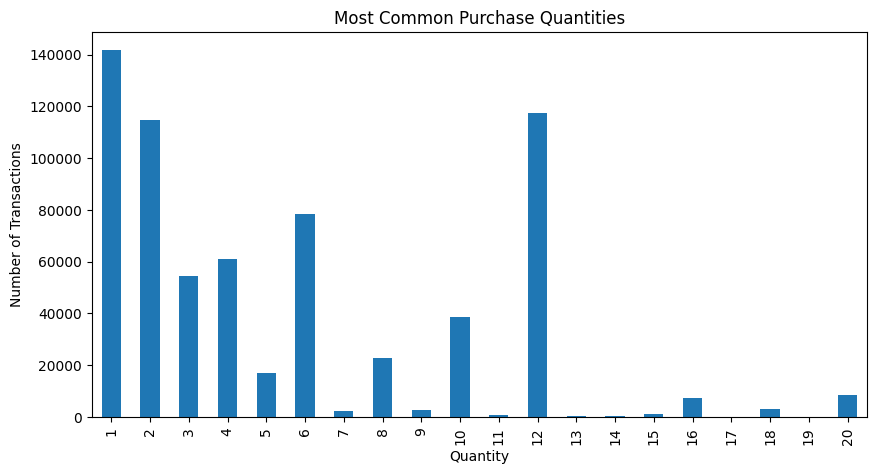

In [12]:
# Set figure size
plt.figure(figsize=(10,5))

# Plot bar chart
quantity_freq.plot(kind="bar")

# Add title and axis labels
plt.title("Most Common Purchase Quantities")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")

# Display the chart
plt.show()


### Outlier Analysis

In [13]:
# Calculate the first and third quartiles
Q1 = df_copy["Quantity"].quantile(0.25)
Q3 = df_copy["Quantity"].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define lower and upper bounds for outlier detection
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Filter outlier records
outliers = df_copy[
    (df_copy["Quantity"] < lower) |
    (df_copy["Quantity"] > upper)
]

# Display the total number of outliers
print(f"Total Outliers: {len(outliers)}")

Total Outliers: 51119


In [14]:
outlier_percentage = (len(outliers) / len(df_copy)) * 100

print(f"Outlier Percentage: {outlier_percentage:.2f}%")

Outlier Percentage: 6.56%


In [15]:
outliers.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
54,489438,21329,DINOSAURS WRITING SET,28,2009-12-01 09:24:00,0.98,18102,United Kingdom
55,489438,21252,SET OF MEADOW FLOWER STICKERS,30,2009-12-01 09:24:00,1.69,18102,United Kingdom
56,489438,21100,CHARLIE AND LOLA CHARLOTTE BAG,30,2009-12-01 09:24:00,1.15,18102,United Kingdom
57,489438,21033,JUMBO BAG CHARLIE AND LOLA TOYS,30,2009-12-01 09:24:00,2.00,18102,United Kingdom


### Outlier Analysis

Outliers were identified

These observations were **not removed** during EDA because they may represent genuine bulk purchases rather than data entry errors.


### Business Insight

- Most transactions involve purchasing a small number of items.
- Large purchase quantities occur less frequently and are identified as outliers.
- These outliers may represent bulk purchases or wholesale orders 

# Unit Price Analysis

This section analyzes the distribution of product prices to understand pricing patterns and identify unusually high-priced products.

In [16]:
# Summary statistics for Price
df_copy["Price"].describe()

count    779425.000000
mean          3.218488
std          29.676140
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max       10953.500000
Name: Price, dtype: float64

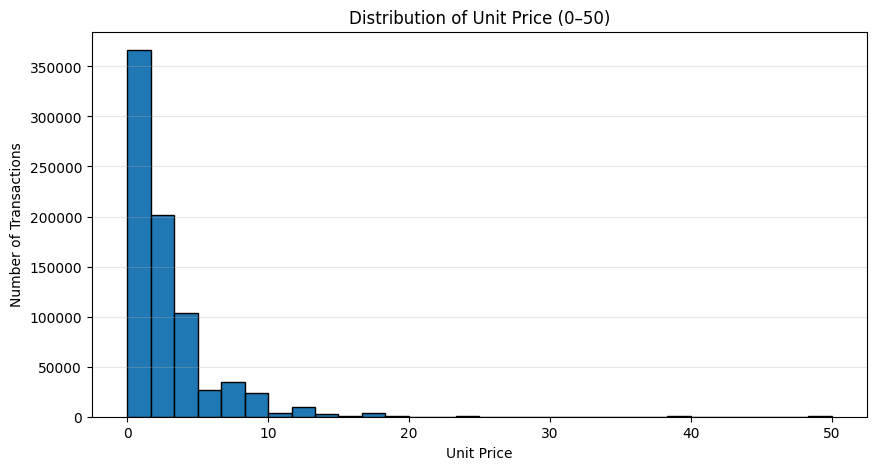

In [17]:
plt.figure(figsize=(10,5))

plt.hist(
    df_copy[df_copy["Price"] <= 50]["Price"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Unit Price (0–50)")
plt.xlabel("Unit Price")
plt.ylabel("Number of Transactions")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Price Outlier Analysis

In [18]:
Q1 = df_copy["Price"].quantile(0.25)
Q3 = df_copy["Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

price_outliers = df_copy[
    (df_copy["Price"] < lower) |
    (df_copy["Price"] > upper)
]

print("Total Price Outliers:", len(price_outliers))
print(f"Outlier Percentage: {(len(price_outliers)/len(df_copy))*100:.2f}%")

Total Price Outliers: 65463
Outlier Percentage: 8.40%


In [19]:
outliers.sort_values("Price", ascending=False).head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
540311,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098,United Kingdom
299844,526945,21769,VINTAGE POST OFFICE CABINET,34,2010-10-14 10:30:00,52.78,18102,United Kingdom
200676,515281,84078A,SET/4 WHITE RETRO STORAGE CUBES,85,2010-07-09 13:53:00,34.95,13734,United Kingdom
254937,522139,84078A,SET/4 WHITE RETRO STORAGE CUBES,40,2010-09-13 10:30:00,34.95,14156,EIRE
200735,515296,84078A,SET/4 WHITE RETRO STORAGE CUBES,85,2010-07-09 15:20:00,34.95,13734,United Kingdom
341476,531515,22833,HALL CABINET WITH 3 DRAWERS,34,2010-11-08 16:44:00,32.69,18102,United Kingdom
397260,537659,22833,HALL CABINET WITH 3 DRAWERS,72,2010-12-07 16:43:00,32.69,18102,United Kingdom
682899,572209,23485,BOTANICAL GARDENS WALL CLOCK,120,2011-10-21 12:08:00,20.80,18102,United Kingdom
400021,538063,22830,UTILTY CABINET WITH HOOKS,96,2010-12-09 13:44:00,19.94,18102,United Kingdom
341477,531515,22830,UTILTY CABINET WITH HOOKS,34,2010-11-08 16:44:00,19.84,18102,United Kingdom


### Price Outlier Analysis

Outliers were identified using the Interquartile Range (IQR) method.

A total of **65,463** transactions (approximately **8.40%** of the dataset) were identified as price outliers.

These records were **not removed**, as they may represent genuine high-value or premium products rather than data quality issues.

### Business Insight

- Most products are priced in the lower price range.
- The price distribution is positively skewed due to a few high-priced transactions.
- Price outliers were identified but retained, as they may represent genuine premium items or business-related charges.

## Time-based Analysis

In [20]:
# Create time-related columns
df_copy["Year"] = df_copy["InvoiceDate"].dt.year
df_copy["Month"] = df_copy["InvoiceDate"].dt.month_name()
df_copy["Month_Num"] = df_copy["InvoiceDate"].dt.month
df_copy["Day"] = df_copy["InvoiceDate"].dt.day_name()
df_copy["Hour"] = df_copy["InvoiceDate"].dt.hour

### Year-wise Transactions

This analysis shows the total number of transactions recorded in each year, helping identify overall business activity and compare sales volume across different years.


In [21]:
yearly_transactions = pd.pivot_table(
    df_copy,
    index="Year",
    values="Invoice",
    aggfunc="count"
)

yearly_transactions

,Invoice
Year,
2009,30272
2010,382130
2011,367023


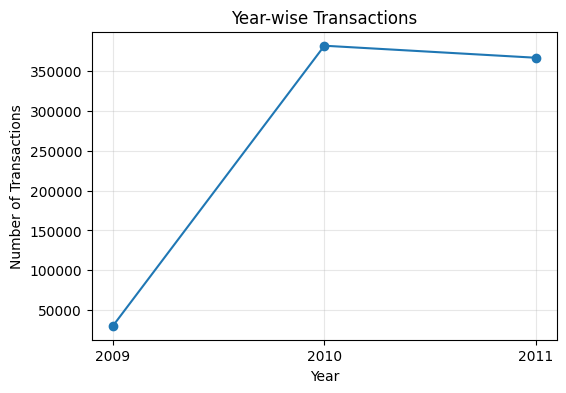

In [22]:
plt.figure(figsize=(6,4))

plt.plot(
    yearly_transactions.index.astype(str),
    yearly_transactions["Invoice"],
    marker="o"
)

plt.title("Year-wise Transactions")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")

plt.grid(alpha=0.3)

plt.show()

### Business Insight

* **2010** recorded the highest number of transactions.
* **2011** maintained a similarly high transaction volume with a slight decline.
* **2009** had fewer transactions, likely due to partial-year data.


### Transactions by Year-Month

This analysis shows the number of transactions for each month across different years, helping identify monthly trends, seasonal patterns, and changes in business activity over time.


In [23]:
df_copy["Year_Month"] = df_copy["InvoiceDate"].dt.to_period("M").astype(str)

In [24]:
monthly_transactions = (
    df_copy.groupby("Year_Month")
    .size()
    .reset_index(name="Transactions")
)

monthly_transactions

,Year_Month,Transactions
0,2009-12,30272
1,2010-01,21458
2,2010-02,23040
3,2010-03,31782
4,2010-04,26831
5,2010-05,28233
6,2010-06,30688
7,2010-07,26643
8,2010-08,26029
9,2010-09,34128


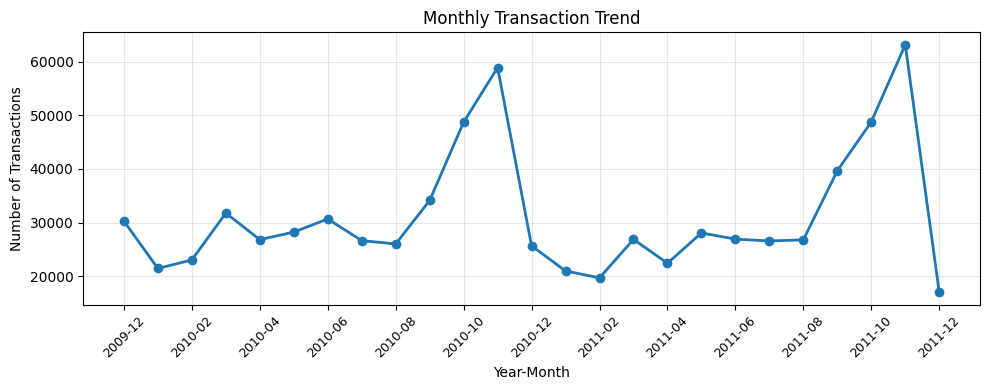

In [25]:
plt.figure(figsize=(10,4))

plt.plot(
    monthly_transactions["Year_Month"],
    monthly_transactions["Transactions"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Transaction Trend")
plt.xlabel("Year-Month")
plt.ylabel("Number of Transactions")

# Show every 2nd label
plt.xticks(
    ticks=range(0, len(monthly_transactions), 2),
    labels=monthly_transactions["Year_Month"][::2],
    rotation=45,
    fontsize=9
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Business Insight

* Transaction volume generally increased toward the end of each year.
* **November 2011** recorded the highest number of transactions (**63,168**), indicating peak business activity.
* Transaction counts were comparatively lower at the beginning of the year and highest during the festive/holiday season (October–November).


## Top 10 Products

In [ ]:
top_products = df_copy.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
print(top_products)


Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64


<Axes: xlabel='Description'>

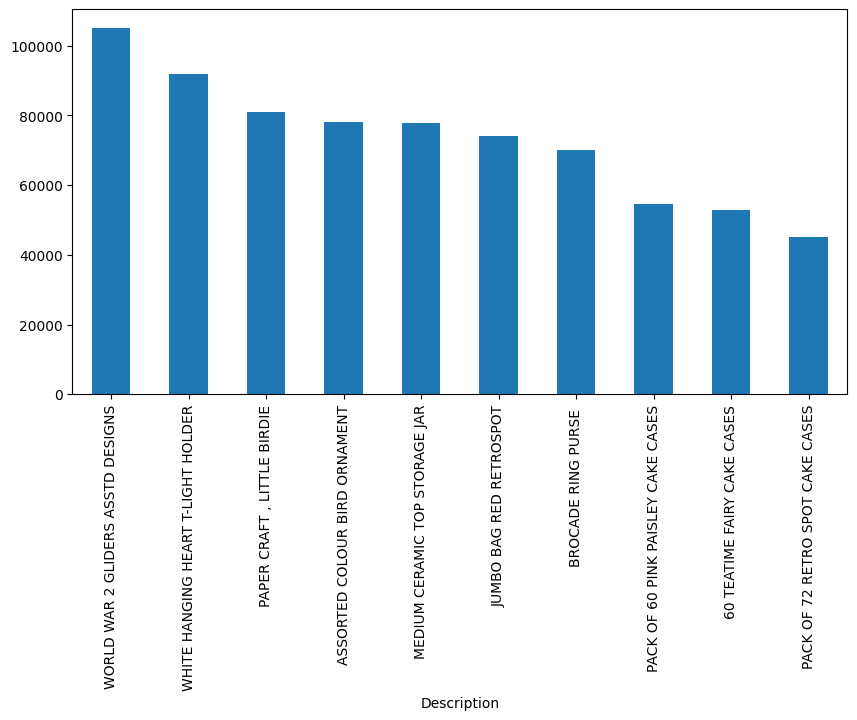

In [27]:
top_products.plot(kind="bar", figsize=(10,5))

### Business Insight

* **WORLD WAR 2 GLIDERS ASSTD DESIGNS** is the best-selling product with **105,185 units** sold.
* **WHITE HANGING HEART T-LIGHT HOLDER** is the second most sold product.
* The **Top 10 products** have very high sales, showing they are the most popular items.
* These products should be kept well-stocked and promoted to maximize sales.



## Top Products by Revenue

In [44]:
product_revenue = (
    df_copy.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

product_revenue.to_frame(name="Revenue")

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,277656.25
WHITE HANGING HEART T-LIGHT HOLDER,247048.01
"PAPER CRAFT , LITTLE BIRDIE",168469.60
Manual,151777.67
JUMBO BAG RED RETROSPOT,134307.44
POSTAGE,124648.04
ASSORTED COLOUR BIRD ORNAMENT,124351.86
PARTY BUNTING,103283.38
MEDIUM CERAMIC TOP STORAGE JAR,81416.73


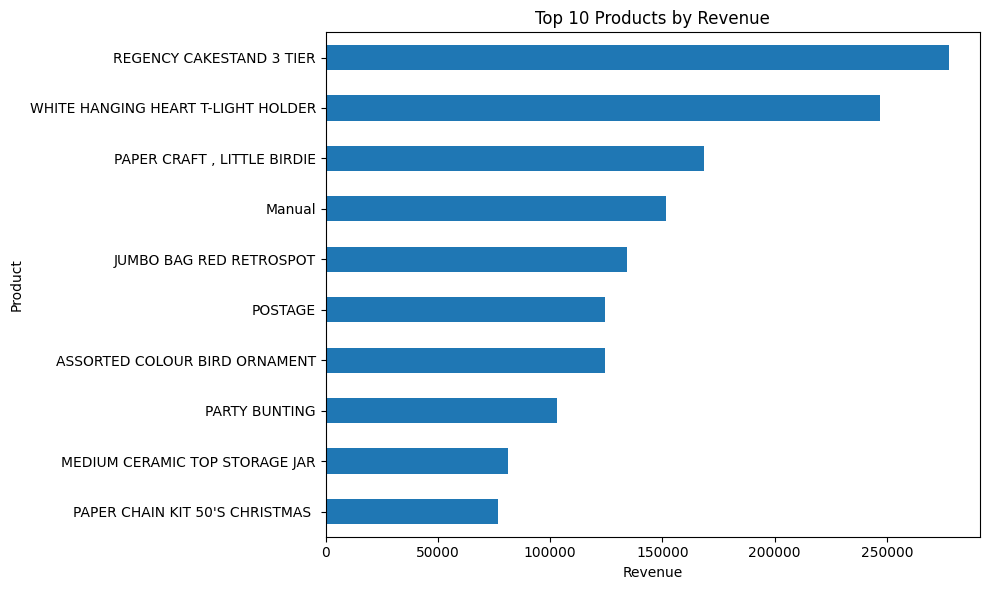

In [43]:
plt.figure(figsize=(10, 6))
product_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

## Top 10 Customers

In [28]:
df_copy["Revenue"] = df_copy["Quantity"] * df_copy["Price"]

top_customers = df_copy.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer ID
18102    580987.04
14646    528602.52
14156    313437.62
14911    291420.81
17450    244784.25
13694    195640.69
17511    172132.87
16446    168472.50
16684    147142.77
12415    144458.37
Name: Revenue, dtype: float64


<Axes: xlabel='Customer ID'>

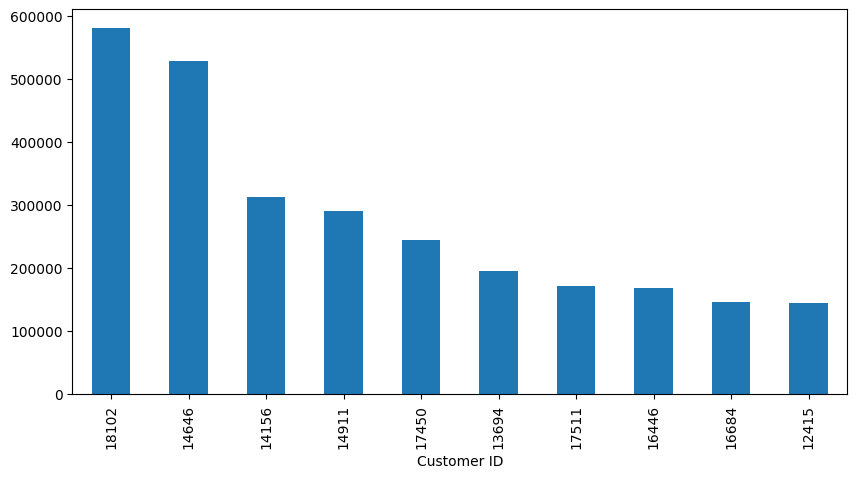

In [29]:
top_customers.plot(kind="bar", figsize=(10,5))

### Business Insight

* **Customer ID 18102** is the highest revenue-generating customer (**580,987.04**).
* The **Top 10 customers** contribute a significant share of total revenue.
* Revenue is concentrated among a few high-value customers.
* The company should focus on **customer retention** and **loyalty programs** for these customers.




## Customer Purchase Frequency

In [40]:
customer_frequency = (
    df_copy.groupby("Customer ID")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

customer_frequency.to_frame(name="Number of Orders")

,Number of Orders
Customer ID,
14911,398
12748,336
17841,211
15311,208
13089,203
14606,192
14156,156
17850,155
14646,151


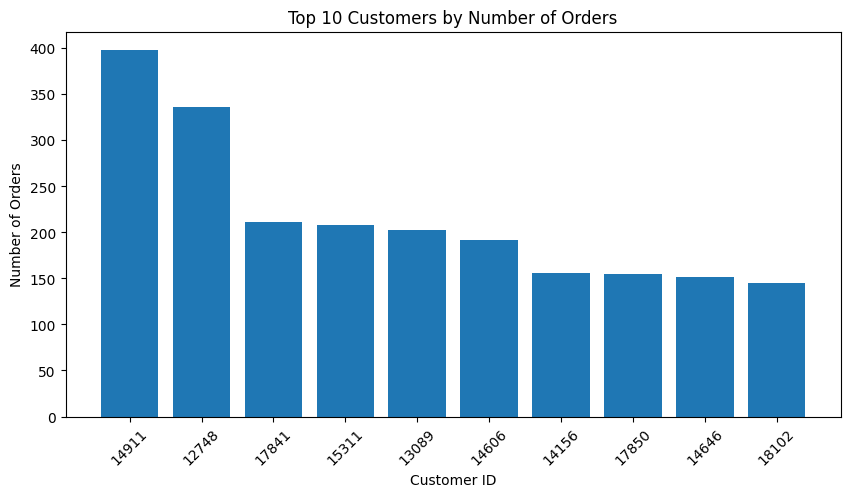

In [41]:
plt.figure(figsize=(10,5))

plt.bar(
    customer_frequency.index.astype(str),
    customer_frequency.values
)

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

### Customer Purchase Frequency - Insight

- Customer **14911** placed the highest number of orders (**398**), followed by **12748** (**336**).
- A small group of customers places orders very frequently, indicating a strong base of loyal and repeat buyers.
- Retaining these high-value customers through loyalty programs and personalized offers can improve long-term revenue.

## Country-wise Sales

In [30]:
country_sales = df_copy.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
print(country_sales.head(10))

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64


<Axes: xlabel='Country'>

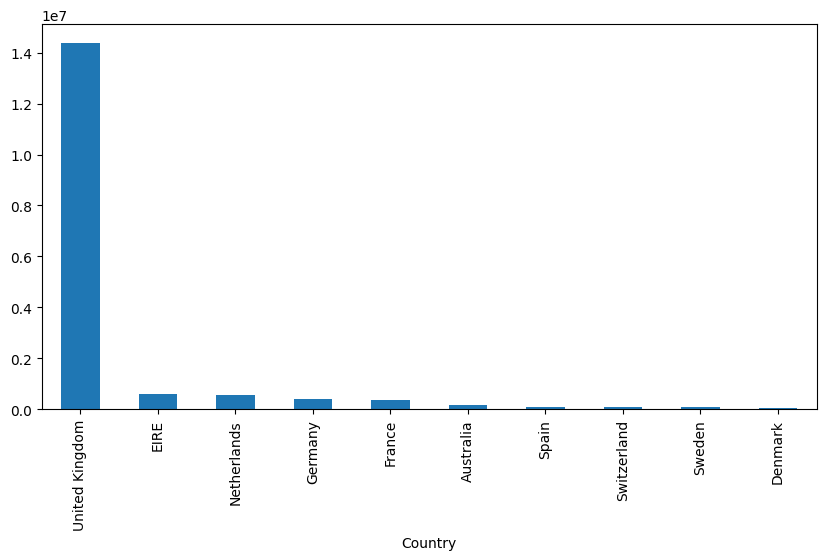

In [31]:
country_sales.head(10).plot(kind="bar", figsize=(10,5))

## Business Insight

* **United Kingdom** generated the highest sales revenue (**14.39 million**), far exceeding all other countries.
* **EIRE** and **Netherlands** are the second and third highest revenue-generating countries.
* Most of the revenue comes from a few countries, with the **United Kingdom dominating sales**.
* The company should maintain its strong presence in the UK while expanding in other high-potential markets.




## Day of Week Analysis

In [33]:
day_sales = df_copy.groupby("Day")["Revenue"].sum().reindex([
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
])

print(day_sales)

Day
Monday       2778201.566
Tuesday      3322830.142
Wednesday    3021043.853
Thursday     3745783.432
Friday       2728473.173
Saturday        9803.050
Sunday       1768669.052
Name: Revenue, dtype: float64


## Business Insight

* **Thursday** recorded the highest sales revenue (**3.75 million**).
* **Tuesday** and **Wednesday** also showed strong sales performance.
* **Saturday** had the lowest sales revenue (**9.8 thousand**).
* Sales are highest on **weekdays**, indicating customers purchase more during the working week.


## Hourly Sales

In [34]:
hourly_sales = df_copy.groupby("Hour")["Revenue"].sum()

print(hourly_sales)

Hour
6           4.250
7       75745.570
8      524612.550
9     1484450.541
10    2320711.443
11    2235870.393
12    2690583.501
13    2347078.714
14    1962016.161
15    1839607.762
16    1055274.691
17     484477.632
18     190860.290
19     124825.770
20      38685.000
Name: Revenue, dtype: float64


## Business Insight

* **12 PM** recorded the highest sales revenue (**2.69 million**).
* Sales remain strong between **10 AM and 3 PM**, indicating peak shopping hours.
* Sales decline significantly after **4 PM** and are lowest during **early morning (6–7 AM)** and **evening (8 PM)**.
* The business should focus promotions and staffing during **10 AM–3 PM** to maximize sales.


## Basket-size Anaalysis

In [35]:
basket_size = df_copy.groupby("Invoice")["Quantity"].sum()

print("Average Basket Size:", basket_size.mean())

Average Basket Size: 284.3991452297871


## Business Insight

* The average basket size is 284.40 items per order.
* This indicates that customers purchase multiple items in a single transaction.
* The business can further increase sales through bundle offers and cross-selling strategies.

## Average Revenue per Invoice

In [45]:
invoice_revenue = (
    df_copy.groupby("Invoice")["Revenue"]
    .sum()
)

invoice_revenue.describe()

count     36969.000000
mean        469.983074
std        1359.741927
min           0.380000
25%         157.920000
50%         303.040000
75%         477.280000
max      168469.600000
Name: Revenue, dtype: float64

### Business Insight

- Most invoices generate relatively low to moderate revenue.
- A few invoices contribute exceptionally high revenue, indicating the presence of high-value transactions (outliers).
- This suggests that overall revenue is influenced by a small number of large orders.

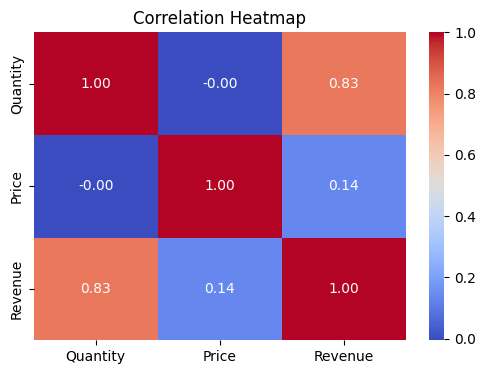

          Quantity     Price   Revenue
Quantity  1.000000 -0.004880  0.827162
Price    -0.004880  1.000000  0.135984
Revenue   0.827162  0.135984  1.000000


In [36]:
corr = df_copy[["Quantity", "Price", "Revenue"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print(corr)

## Business Insight

* Quantity and Revenue have a strong positive correlation (0.83), meaning higher quantities sold lead to higher revenue.
* Price and Revenue have a weak positive correlation (0.14), indicating price has a limited impact on revenue.
* Quantity and Price have almost no correlation (-0.005), showing that product quantity sold is largely independent of price.

## Summary

✔ Performed exploratory data analysis to understand customer purchasing behavior and sales patterns.

✔ Analyzed transaction trends across time, products, customers, countries, and order characteristics.

✔ Identified data distributions, correlations, and potential outliers without modifying the dataset.

✔ Derived business insights to support customer segmentation, demand forecasting, inventory optimization, and dashboard development.

The insights obtained from this analysis will guide the feature engineering and machine learning stages of the project.